# Unitree A1 Quadruped Trot-Gait Controller

Jianguo Zhao, Colorado State University

**Based on the Code by Prof. Pranav A. Bhounsule**:
[Unitree A1 quadruped](https://pab47.github.io/robotics/robotics25.html)

---

## Overview

This notebook implements a complete trot-gait walking controller for the **Unitree A1** quadruped robot, simulated in [MuJoCo](https://mujoco.org/).
Starting from a single high-level velocity command, the controller computes 12 motor torques at every simulation timestep so the robot walks at the desired speed while remaining stable.

### The Robot: Unitree A1

The A1 is a 12-DOF legged robot with four 3-DOF legs (abduction · hip · knee).
Its free-floating trunk adds 6 more DOFs (position + orientation), giving **19 generalized coordinates** in MuJoCo:

```
qpos = [x, y, z, qw, qx, qy, qz | q_FR(3) | q_FL(3) | q_RR(3) | q_RL(3)]
          └──── trunk (7) ────┘  └──────────── legs (12) ──────────────┘
```

Leg numbering: **0 = FR**, **1 = FL**, **2 = RR**, **3 = RL**.
Trot gait uses two diagonal pairs that move in anti-phase: {FR, RL} and {FL, RR}.

### Key Physical Parameters (Zero Position)

| Parameter | Value |
|-----------|-------|
| L (thigh/shank link length) | 0.2 m |
| W (hip offset width) | 0.047 m |
| C (half body length from center to hip) | 0.183 m |

The **zero position** has all joints at θ = 0, with the robot standing upright and feet directly below the hip joints. The **yellow dot** marks the foot end-effector (below the white dot when all angles = 0).

---

## Control Goal

> **Given** a desired body velocity $(\dot x_\text{ref},\, \dot y_\text{ref},\, \dot\psi_\text{ref})$,
> compute 12 joint torques every timestep so the robot walks at those speeds while staying upright.

The challenge: the input is a velocity command; the output must be low-level joint torques.
The solution decomposes into **three nested layers**:

| Layer | Question answered | Key tools |
|:---:|---|---|
| **1 · Gait Planning** | Where does each foot land next? | Finite-state machine, Raibert heuristic |
| **2 · Kinematics** | How must joints move to put feet there? | Quintic polynomial, IK, Jacobian |
| **3 · Dynamics** | What torques produce the required forces? | Newton-Euler wrench balance, PD, $-J^T F$ |

### Complete Data Flow

```
Desired velocity  (xdot_ref, ydot_ref, psidot_ref)
       |
       v  [once per gait cycle]
high_level_control()   -- rate-limit and saturate velocity commands
       |
       v  [every timestep]
state_machine()        -- decide swing/stance per leg; set Raibert foot arc endpoints
       |
       v
cartesian_traj()       -- smooth foot references via quintic_poly()
  |-- quintic_poly()   -- 5th-order polynomial, zero vel/accel at endpoints
       |
       |-- inverse_kinematics_analytic()  --> q_ref  (joint angles)
       `-- jac_end_effector_leg()   --> J  --> qdot_ref = J^-1 * ldot_ref
joint_traj()
       |
       v  [stance legs only]
stance_force()
  |-- forward_kinematics_robot()   -- foot positions and COM (lever arms for A)
  |-- assemble A from lever arms   -- Newton-Euler wrench balance matrix
  |-- compute b from PD on trunk   -- desired net force/moment
  `-- F = pinv(A) * b              -- solve for ground reaction forces
       |
       v
joint_control()
  |-- PD(q_ref - q_act)            -- all legs: track joint reference
  `-- -J^T * F_contact             -- stance legs: feedforward from contact force
       |
       v
data.ctrl = q_act + tau / Kp       -- position-actuator encoding
       |
       v
mj_step()                          -- integrate full dynamics
```

### Why Each Tool Is Necessary

| Tool | Role in the pipeline |
|---|---|
| **Raibert heuristic** | The only place $\dot{x}_\text{ref}$ enters the leg geometry — maps speed to step length |
| **Quintic polynomial** | Guarantees zero velocity/acceleration at lift-off and touch-down, eliminating impact spikes |
| **Inverse kinematics** | Solves the nonlinear geometry: Cartesian foot target → 3 joint angles |
| **Forward kinematics** | Finds foot positions and COM in world frame — needed to build the lever-arm matrix $A$ |
| **Jacobian** | Bridges two directions: Cartesian velocity → joint velocity (trajectory), and foot force → joint torque (control) |
| **Newton-Euler + $A^+$** | Distributes a 6-DOF trunk wrench across two stance legs — pure statics, no dynamics inversion |
| **PD in joint space** | Handles model error and swing-leg tracking |
| **$-J^T F$ feedforward** | Principle of virtual work: exact joint torques to produce the desired foot force |

---

In [ ]:
# Install / configure (safe to re-run; Colab skips already-installed packages)
%pip install -q mujoco mediapy pandas matplotlib

import os
os.environ['MUJOCO_GL'] = 'egl'   # headless EGL renderer — required in Colab
print("Environment ready.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.4 MB/s eta 0:00:00
Environment ready.


## Support — Utility Functions (`utility.py`)

Provides rotation matrix helpers (`rotation`, `quat2mat`, `quat2bryant`), quaternion arithmetic, and **`vec2skew(v)`** which builds the $3\times3$ skew-symmetric matrix $S(\mathbf{v})$ satisfying $S(\mathbf{v})\,\mathbf{w} = \mathbf{v}\times\mathbf{w}$.

In [ ]:
import numpy as np
import sys, types

_FLOAT_EPS = np.finfo(np.float64).eps # smallest representable positive number such that 1.0 + _FLOAT_EPS != 1.0
_EPS4 = _FLOAT_EPS * 4.0 # threshold for near-zero in 4D (e.g. quaternion) computations

# rotation matrix for rotation of 'angle' radians about 'axis' (0,1,2 for x,y,z)
def rotation(angle, axis):
    c, s = np.cos(angle), np.sin(angle)
    if axis == 0:
        return np.array([[1,0,0],[0,c,-s],[0,s,c]])
    elif axis == 1:
        return np.array([[c,0,s],[0,1,0],[-s,0,c]])
    elif axis == 2:
        return np.array([[c,-s,0],[s,c,0],[0,0,1]])
    raise ValueError('axis must be 0, 1, or 2')

# convert quaternion to rotation matrix
def quat2rotation(q):
    q0,q1,q2,q3 = q
    return np.array([
        [q0**2+q1**2-q2**2-q3**2, 2*(q1*q2-q0*q3),           2*(q1*q3+q0*q2)],
        [2*(q1*q2+q0*q3),         q0**2-q1**2+q2**2-q3**2,   2*(q2*q3-q0*q1)],
        [2*(q1*q3-q0*q2),         2*(q2*q3+q0*q1),           q0**2-q1**2-q2**2+q3**2]])

# convert rotation matrix to quaternion
def rotation2quat(R):
    q0 = np.sqrt(max(0.0,1+R[0,0]+R[1,1]+R[2,2]))/2
    q1 = np.sqrt(max(0.0,1+R[0,0]-R[1,1]-R[2,2]))/2
    q2 = np.sqrt(max(0.0,1-R[0,0]+R[1,1]-R[2,2]))/2
    q3 = np.sqrt(max(0.0,1-R[0,0]-R[1,1]+R[2,2]))/2
    if q0 >= max(q1,q2,q3):
        q1=(R[2,1]-R[1,2])/(4*q0); q2=(R[0,2]-R[2,0])/(4*q0); q3=(R[1,0]-R[0,1])/(4*q0)
    elif q1 >= max(q0,q2,q3):
        q0=(R[2,1]-R[1,2])/(4*q1); q2=(R[1,0]+R[0,1])/(4*q1); q3=(R[0,2]+R[2,0])/(4*q1)
    elif q2 >= max(q0,q1,q3):
        q0=(R[0,2]-R[2,0])/(4*q2); q1=(R[1,0]+R[0,1])/(4*q2); q3=(R[2,1]+R[1,2])/(4*q2)
    else:
        q0=(R[1,0]-R[0,1])/(4*q3); q1=(R[0,2]+R[2,0])/(4*q3); q2=(R[2,1]+R[1,2])/(4*q3)
    return np.array([q0,q1,q2,q3])

# convert quaternion to axis-angle representation (axis unit vector, angle in radians)
def quat2axisangle(quat):
    q0,qx,qy,qz = quat
    angle = 2*np.arccos(np.clip(q0,-1,1))
    sh = np.sin(angle/2)
    axis = np.array([1,0,0]) if sh < 1e-6 else np.array([qx,qy,qz])/sh
    return axis, angle

# convert Euler angles (roll, pitch, yaw) to rotation matrix and back
def euler2rotation(euler):
    return rotation(euler[0],0) @ rotation(euler[1],1) @ rotation(euler[2],2)

# convert rotation matrix to Euler angles (roll, pitch, yaw)
def rotation2euler(R):
    theta = np.arcsin(np.clip(R[0,2],-1,1))
    ct = np.cos(theta)
    psi = np.arcsin(np.clip(-R[0,1]/ct,-1,1))
    phi = np.arcsin(np.clip(-R[1,2]/ct,-1,1))
    return np.array([phi,theta,psi])

def quat2euler(q):    return rotation2euler(quat2rotation(q))
def euler2quat(euler): return rotation2quat(euler2rotation(euler))

def quat_conjugate(q):
    c = -q.copy(); c[0] = q[0]; return c

def quat_product(q,p):
    q0,p0 = q[0],p[0]
    qv,pv = q[1:4],p[1:4]
    return np.r_[q0*p0-qv@pv, q0*pv+p0*qv+np.cross(qv,pv)]

def quat_normalize(q):
    return q / np.linalg.norm(q, axis=-1, keepdims=True)

def vec2skew(v):
    return np.array([[0,-v[2],v[1]],[v[2],0,-v[0]],[-v[1],v[0],0]])

# convert rotation matrix to quaternion
def mat2quat(mat):
    mat = np.asarray(mat, dtype=np.float64)
    Qxx,Qyx,Qzx = mat[...,0,0],mat[...,0,1],mat[...,0,2]
    Qxy,Qyy,Qzy = mat[...,1,0],mat[...,1,1],mat[...,1,2]
    Qxz,Qyz,Qzz = mat[...,2,0],mat[...,2,1],mat[...,2,2]
    K = np.zeros(mat.shape[:-2]+(4,4), dtype=np.float64)
    K[...,0,0]=Qxx-Qyy-Qzz; K[...,1,0]=Qyx+Qxy; K[...,1,1]=Qyy-Qxx-Qzz
    K[...,2,0]=Qzx+Qxz;     K[...,2,1]=Qzy+Qyz; K[...,2,2]=Qzz-Qxx-Qyy
    K[...,3,0]=Qyz-Qzy;     K[...,3,1]=Qzx-Qxz; K[...,3,2]=Qxy-Qyx
    K[...,3,3]=Qxx+Qyy+Qzz; K /= 3.0
    q = np.empty(K.shape[:-2]+(4,))
    it = np.nditer(q[...,0], flags=['multi_index'])
    while not it.finished:
        vals,vecs = np.linalg.eigh(K[it.multi_index])
        q[it.multi_index] = vecs[[3,0,1,2],np.argmax(vals)]
        if q[it.multi_index][0] < 0: q[it.multi_index] *= -1
        it.iternext()
    return q

# convert quaternion to rotation matrix
def quat2mat(quat):
    quat = np.asarray(quat, dtype=np.float64)
    w,x,y,z = quat[...,0],quat[...,1],quat[...,2],quat[...,3]
    Nq = np.sum(quat*quat,axis=-1); s = 2.0/Nq
    X,Y,Z = x*s,y*s,z*s
    wX,wY,wZ = w*X,w*Y,w*Z
    xX,xY,xZ = x*X,x*Y,x*Z
    yY,yZ,zZ  = y*Y,y*Z,z*Z
    mat = np.empty(quat.shape[:-1]+(3,3), dtype=np.float64)
    mat[...,0,0]=1.0-(yY+zZ); mat[...,0,1]=xY-wZ;       mat[...,0,2]=xZ+wY
    mat[...,1,0]=xY+wZ;       mat[...,1,1]=1.0-(xX+zZ); mat[...,1,2]=yZ-wX
    mat[...,2,0]=xZ-wY;       mat[...,2,1]=yZ+wX;       mat[...,2,2]=1.0-(xX+yY)
    return np.where((Nq>_FLOAT_EPS)[...,np.newaxis,np.newaxis], mat, np.eye(3))

def quat2bryant(quat): return mat2bryant(quat2mat(quat))

def bryant2quat(euler):
    euler = np.asarray(euler, dtype=np.float64)
    ai,aj,ak = euler[...,2]/2,-euler[...,1]/2,euler[...,0]/2
    si,sj,sk = np.sin(ai),np.sin(aj),np.sin(ak)
    ci,cj,ck = np.cos(ai),np.cos(aj),np.cos(ak)
    cc,cs,sc,ss = ci*ck,ci*sk,si*ck,si*sk
    quat = np.empty(euler.shape[:-1]+(4,), dtype=np.float64)
    quat[...,0]=cj*cc+sj*ss; quat[...,1]=cj*cs-sj*sc
    quat[...,2]=-(cj*ss+sj*cc); quat[...,3]=cj*sc-sj*cs
    return quat

def mat2bryant(mat):
    mat = np.asarray(mat, dtype=np.float64)
    cy = np.sqrt(mat[...,2,2]**2+mat[...,1,2]**2)
    cond = cy > _EPS4
    euler = np.empty(mat.shape[:-1], dtype=np.float64)
    euler[...,2] = np.where(cond, -np.arctan2(mat[...,0,1],mat[...,0,0]),
                                  -np.arctan2(-mat[...,1,0],mat[...,1,1]))
    euler[...,1] = -np.arctan2(-mat[...,0,2], cy)
    euler[...,0] = np.where(cond, -np.arctan2(mat[...,1,2],mat[...,2,2]), 0.0)
    return euler

def bryant2mat(euler):
    euler = np.asarray(euler, dtype=np.float64)
    ai,aj,ak = -euler[...,2],-euler[...,1],-euler[...,0]
    si,sj,sk = np.sin(ai),np.sin(aj),np.sin(ak)
    ci,cj,ck = np.cos(ai),np.cos(aj),np.cos(ak)
    cc,cs,sc,ss = ci*ck,ci*sk,si*ck,si*sk
    mat = np.empty(euler.shape[:-1]+(3,3), dtype=np.float64)
    mat[...,2,2]=cj*ck; mat[...,2,1]=sj*sc-cs; mat[...,2,0]=sj*cc+ss
    mat[...,1,2]=cj*sk; mat[...,1,1]=sj*ss+cc; mat[...,1,0]=sj*cs-sc
    mat[...,0,2]=-sj;   mat[...,0,1]=cj*si;    mat[...,0,0]=cj*ci
    return mat

def quat2angvelBody(quat,quatd):
    qc = quat_conjugate(quat); qc = qc/np.linalg.norm(qc)
    return 2*quat_product(qc,quatd)

def quat2angvelWorld(quat,quatd):
    qc = quat_conjugate(quat); qc = qc/np.linalg.norm(qc)
    return 2*quat_product(quatd,qc)

def quat2angaccBody(quat,quatd,quatdd):
    qc  = quat_conjugate(quat);  qc  = qc /np.linalg.norm(qc)
    qdc = quat_conjugate(quatd); qdc = qdc/np.linalg.norm(qdc)
    return 2*quat_product(qc,quatdd)+2*quat_product(qdc,quatd)

def quat2angaccWorld(quat,quatd,quatdd):
    qc  = quat_conjugate(quat);  qc  = qc /np.linalg.norm(qc)
    qdc = quat_conjugate(quatd); qdc = qdc/np.linalg.norm(qdc)
    return 2*quat_product(quatdd,qc)+2*quat_product(qdc,quatd)

# register as importable module
_m = types.ModuleType('utility')
_m._FLOAT_EPS = _FLOAT_EPS; _m._EPS4 = _EPS4
for _f in [rotation,quat2rotation,rotation2quat,quat2axisangle,euler2rotation,
           rotation2euler,quat2euler,euler2quat,quat_conjugate,quat_product,
           quat_normalize,vec2skew,mat2quat,quat2mat,quat2bryant,bryant2quat,
           mat2bryant,bryant2mat,quat2angvelBody,quat2angvelWorld,
           quat2angaccBody,quat2angaccWorld]:
    setattr(_m, _f.__name__, _f)
sys.modules['utility'] = _m
print('utility registered')

utility registered


## Support — Robot Body Data (`robot_data.py`)

Stores kinematic chain geometry (joint positions, orientations) and inertial parameters (mass, inertia tensors) parsed from the Unitree A1 URDF. Used by `forward_kinematics_robot()` to traverse the kinematic tree.

In [ ]:
import numpy as np
import utility as ram

class Robot:
    class Body:
        def __init__(self, parent, name, pos, quat, ipos, iquat,
                     mass, inertia, joint_axis, joint_range):
            self.parent=parent; self.name=name
            self.pos=np.array(pos); self.quat=np.array(quat)
            self.ipos=np.array(ipos); self.iquat=np.array(iquat)
            self.mass=mass; self.inertia=np.array(inertia)
            self.joint_axis=np.array(joint_axis)
            self.joint_range=np.array(joint_range)
    class Params:
        def __init__(self):
            self.end_eff_pos_local = np.array([0,0,-0.2])
            self.q_base = np.array([0,0,0.27,1,0,0,0])
    def __init__(self):
        self.body={}; self.params=Robot.Params()
    def add_body(self,bid,parent,name,pos,quat,ipos,iquat,mass,inertia,joint_axis,joint_range):
        self.body[bid]=Robot.Body(parent,name,pos,quat,ipos,iquat,mass,inertia,joint_axis,joint_range)

# Define the robot structure and parameters (from URDF)
robot = Robot()
robot.add_body(1,'ground','trunk',[0,0,0.43],[1,0,0,0],[0,0.0041,-0.0005],[1,0,0,0],
    4.713,[0.0158533,0.0377999,0.0456542,-3.66e-05,-6.11e-05,-2.75e-05],[0,0,0,1,0,0,0],[-6.28319,6.28319])
robot.add_body(2,'trunk','FR_hip_joint',[0.183,-0.047,0],[1,0,0,0],[-0.003311,-0.000635,3.1e-05],
    [0.507528,0.506268,0.491507,0.494499],0.696,[0.000807752,0.00055293,0.000468983],[1,0,0],[-0.802851,0.802851])
robot.add_body(3,'FR_hip_joint','FR_thigh_joint',[0,-0.08505,0],[1,0,0,0],
    [-0.003237,0.022327,-0.027326],[0.999125,-0.00256393,-0.0409531,-0.00806091],
    1.013,[0.00555739,0.00513936,0.00133944],[0,1,0],[-1.0472,4.18879])
robot.add_body(4,'FR_thigh_joint','FR_calf_joint',[0,0,-0.2],[1,0,0,0],
    [0.00472659,0,-0.131975],[0.706886,0.017653,0.017653,0.706886],
    0.226,[0.00340344,0.00339393,3.54834e-05],[0,1,0],[-2.69653,-0.916298])
robot.add_body(5,'trunk','FL_hip_joint',[0.183,0.047,0],[1,0,0,0],[-0.003311,0.000635,3.1e-05],
    [0.494499,0.491507,0.506268,0.507528],0.696,[0.000807752,0.00055293,0.000468983],[1,0,0],[-0.802851,0.802851])
robot.add_body(6,'FL_hip_joint','FL_thigh_joint',[0,0.08505,0],[1,0,0,0],
    [-0.003237,-0.022327,-0.027326],[0.999125,0.00256393,-0.0409531,0.00806091],
    1.013,[0.00555739,0.00513936,0.00133944],[0,1,0],[-1.0472,4.18879])
robot.add_body(7,'FL_thigh_joint','FL_calf_joint',[0,0,-0.2],[1,0,0,0],
    [0.00472659,0,-0.131975],[0.706886,0.017653,0.017653,0.706886],
    0.226,[0.00340344,0.00339393,3.54834e-05],[0,1,0],[-2.69653,-0.916298])
robot.add_body(8,'trunk','RR_hip_joint',[-0.183,-0.047,0],[1,0,0,0],[0.003311,-0.000635,3.1e-05],
    [0.494499,0.491507,0.506268,0.507528],0.696,[0.000807752,0.00055293,0.000468983],[1,0,0],[-0.802851,0.802851])
robot.add_body(9,'RR_hip_joint','RR_thigh_joint',[0,-0.08505,0],[1,0,0,0],
    [-0.003237,0.022327,-0.027326],[0.999125,-0.00256393,-0.0409531,-0.00806091],
    1.013,[0.00555739,0.00513936,0.00133944],[0,1,0],[-1.0472,4.18879])
robot.add_body(10,'RR_thigh_joint','RR_calf_joint',[0,0,-0.2],[1,0,0,0],
    [0.00472659,0,-0.131975],[0.706886,0.017653,0.017653,0.706886],
    0.226,[0.00340344,0.00339393,3.54834e-05],[0,1,0],[-2.69653,-0.916298])
robot.add_body(11,'trunk','RL_hip_joint',[-0.183,0.047,0],[1,0,0,0],[0.003311,0.000635,3.1e-05],
    [0.507528,0.506268,0.491507,0.494499],0.696,[0.000807752,0.00055293,0.000468983],[1,0,0],[-0.802851,0.802851])
robot.add_body(12,'RL_hip_joint','RL_thigh_joint',[0,0.08505,0],[1,0,0,0],
    [-0.003237,-0.022327,-0.027326],[0.999125,0.00256393,-0.0409531,0.00806091],
    1.013,[0.00555739,0.00513936,0.00133944],[0,1,0],[-1.0472,4.18879])
robot.add_body(13,'RL_thigh_joint','RL_calf_joint',[0,0,-0.2],[1,0,0,0],
    [0.00472659,0,-0.131975],[0.706886,0.017653,0.017653,0.706886],
    0.226,[0.00340344,0.00339393,3.54834e-05],[0,1,0],[-2.69653,-0.916298])

# Normalize quaternions to ensure valid rotations
for _b in robot.body.values():
    _b.quat  = ram.quat_normalize(_b.quat)
    _b.iquat = ram.quat_normalize(_b.iquat)

_m = types.ModuleType('robot_data')
_m.robot = robot; _m.Robot = Robot
sys.modules['robot_data'] = _m
print('robot_data registered')

robot_data registered


## Support — Control Parameters (`parameters.py`)

Defines all tunable constants:
- **Gait timing:** `t_stand`, `t_step`, `lz0`, `hcl`
- **Velocity limits:** `vx_min/max`, `vy_min/max`, `omega_min/max` and ramp rates
- **Physical:** `mass`, `gravity`

All controller functions import `parms` from this module.

In [ ]:
class parameters:
    def __init__(self):
        self.fsm_stand  = 1     # nominal FSM states for stand phase of trot gait
        self.fsm_stance = 2     # nominal FSM states for stance phase of trot gait
        self.fsm_swing  = 3     # nominal FSM states for swing phase of trot gait
        self.t_stand    = 0.1  # nominal stand duration (s)
        self.t_step     = 0.15 # nominal step duration (s)
        self.lz0        = -0.24864398730826576   # overwritten below after FK
        self.hcl        = 0.075  # nominal clearance height for swing foot
        self.mass       = 12.453 # total mass of robot
        self.gravity    = 9.81   # gravitational acceleration (m/s^2)
        self.vx_min=-2.0;  self.vx_max=2.0;  self.dvx=0.1   # desired forward velocity range and step for user input
        self.vy_min=-1.0;  self.vy_max=1.0;  self.dvy=0.05  # desired lateral velocity range and step for user input
        self.omega_min=-2; self.omega_max=2;  self.domega=0.1  # desired angular velocity range and step for user input

parms = parameters()

_m = types.ModuleType('parameters')
_m.parms = parms; _m.parameters = parameters
sys.modules['parameters'] = _m
print('parameters registered')

parameters registered


## Support — Global State (`globals.py`)

A shared-state module holding all runtime variables updated each timestep:
- **FSM state:** `fsm[4]`, `t_fsm[4]`
- **Foot arc endpoints:** `lx_i/f[4]`, `ly_i/f[4]`, `lz_i/f[4]`
- **References:** `q_ref[12]`, `u_ref[12]`, `lx_ref[4]`, …
- **Robot state:** `q_act[12]`, `u_act[12]`, `pos_quat_trunk[7]`, `vel_angvel_trunk[6]`
- **Commands:** `xdot_ref`, `ydot_ref`, `psidot_ref`

Call `init()` once before the simulation loop to reset all variables.

In [ ]:
import numpy as np
from parameters import parms

# Create a real module object so that `import globals` works everywhere
_g = types.ModuleType('globals')
sys.modules['globals'] = _g

# Initialize global variables (call init() before simulation)
def init():
    g = sys.modules['globals']
    from parameters import parms
    import numpy as np

    g.time = 0
    g.fsm   = np.array([parms.fsm_stand]*4)
    g.t_fsm = np.zeros(4)

    g.t_i = np.zeros(4)
    g.t_f = np.array([parms.t_stand]*4)

    g.lx_ref   = np.zeros(4); g.ly_ref   = np.zeros(4); g.lz_ref   = np.zeros(4)
    g.lxdot_ref= np.zeros(4); g.lydot_ref= np.zeros(4); g.lzdot_ref= np.zeros(4)
    g.lx_i     = np.zeros(4); g.lx_f     = np.zeros(4)
    g.ly_i     = np.zeros(4); g.ly_f     = np.zeros(4)
    g.lz_i     = np.array([parms.lz0]*4)
    g.lz_f     = np.array([parms.lz0]*4)

    g.q_ref = np.zeros(12); g.u_ref = np.zeros(12)
    g.q_act = np.zeros(12); g.u_act = np.zeros(12); g.trq = np.zeros(12)

    g.xdot_ref = 0.0; g.ydot_ref = 0.0; g.psidot_ref = 0.0
    g.step = 0; g.prev_step = 0

    g.pos_quat_trunk  = np.zeros(7) # (x,y,z,qw,qx,qy,qz)
    g.vel_angvel_trunk= np.zeros(6) # (xdot,ydot,zdot,wx,wy,wz)

_g.init = init
print('globals module registered (call init() before simulation)')

globals module registered (call init() before simulation)


## Layer 1 — Gait Planning: `state_machine()`

### States

One independent FSM per leg (`leg_no` ∈ {0, 1, 2, 3}):

| Code | Name | Description |
|:---:|---|---|
| 1 | `fsm_stand` | Initialization — all 4 legs hold neutral height |
| 2 | `fsm_stance` | Foot on ground; only $\ell_z$ settles height |
| 3 | `fsm_swing` | Foot airborne; quintic arc to next contact point |

**Trot gait pairing** (anti-phase diagonal pairs):

| Phase A | Phase B |
|---|---|
| FR (0) + RL (3) swing | FL (1) + RR (2) swing |

### Transition Logic

```
Stand  ──(t ≥ t_stand)──▶  {0,3}: Swing,   {1,2}: Stance
Stance ──(t ≥ t_step) ──▶  Swing
Swing  ──(t ≥ t_step) ──▶  Stance
```

### Raibert Foot Placement

$\ell_x$ is measured in the **hip frame** (body-fixed). During stance the foot is fixed in the world while the hip moves forward, so $\ell_x$ decreases from positive (foot ahead at touchdown) to negative (foot behind at liftoff). Placing the foot symmetrically around the neutral point gives stable steady-state speed.

**Swing arc** endpoints (set at Stance → Swing transition):

$$\ell_{x,i} = -\tfrac{1}{2}\dot{x}_\text{ref}\,t_\text{step}, \qquad \ell_{x,f} = +\tfrac{1}{2}\dot{x}_\text{ref}\,t_\text{step}$$

$$\ell_{z,i} = \ell_{z_0}, \qquad \ell_{z,f} = \ell_{z_0} + h_\text{cl}$$

**Stance arc** endpoints (set at Swing → Stance transition, mirrors swing):

$$\ell_{x,i} = +\tfrac{1}{2}\dot{x}_\text{ref}\,t_\text{step}, \qquad \ell_{x,f} = -\tfrac{1}{2}\dot{x}_\text{ref}\,t_\text{step}$$

$$\ell_{z,i} = \ell_{z_0}, \qquad \ell_{z,f} = \ell_{z_0}$$

The lateral $\ell_y$ follows the same mirror pattern plus a **yaw-coupling** term ($c = 0.183$ m, half hip-to-hip spacing). For front legs (0, 1):

$$\ell_{y,i} = -\tfrac{1}{2}\dot{y}_\text{ref}\,t_\text{step} - \tfrac{1}{2}c\,\dot{\psi}_\text{ref}\,t_\text{step}, \qquad \ell_{y,f} = +\tfrac{1}{2}\dot{y}_\text{ref}\,t_\text{step} + \tfrac{1}{2}c\,\dot{\psi}_\text{ref}\,t_\text{step}$$

For rear legs (2, 3) the yaw sign flips. The **Swing → Stance** arc endpoints swap $i$ and $f$ (same mirror logic as $\ell_x$).


In [ ]:
import globals
from parameters import parms

# ── Finite-state machine (FSM) for trot gait ─────────────────────────────────
#
# One independent 3-state FSM per leg (leg_no = 0..3):
#   fsm_stand  (1): initialisation -- all legs settle to nominal height
#   fsm_stance (2): foot on ground; body moves forward over the planted foot
#   fsm_swing  (3): foot airborne; quintic arc carries foot to next contact
#
# Trot pairing (anti-phase diagonal pairs):
#   Pair A: FR (0) + RL (3) swing together
#   Pair B: FL (1) + RR (2) swing together
#
# Raibert heuristic -- foot placement in the hip frame:
#   lx is measured forward from directly below the hip.
#   At touchdown the foot is placed AHEAD (+lx) of the hip; by mid-stance the
#   foot is directly below; at liftoff it is BEHIND (-lx).
#   This symmetric arc around the neutral point gives zero net horizontal push
#   and produces stable walking at the commanded speed.
#
#   Stance->Swing (liftoff):   foot starts behind (-lx_i) and swings to ahead (+lx_f)
#   Swing->Stance (touchdown): foot starts ahead  (+lx_i) and slides to behind (-lx_f)
#
#   Lateral (ly) follows the same mirror pattern, plus a yaw-coupling term
#   +-c*psidot_ref*t_step that steers feet outward on the inside of a turn.
def state_machine():
    time = globals.time
    c    = 0.183   # half hip-to-hip spacing (m) -- yaw coupling lever arm

    for leg_no in range(4):

        # Stand -> Swing (legs 0,3) or Stance (legs 1,2) after t_stand
        # Let the robot settle before starting the gait
        if time >= globals.t_fsm[leg_no]+parms.t_stand and globals.fsm[leg_no]==parms.fsm_stand:
            if leg_no in (0, 3):                         # FR, RL -> swing first
                globals.fsm[leg_no]   = parms.fsm_swing
                globals.lz_f[leg_no]  = parms.lz0 + parms.hcl  # lift to clearance height
            else:                                        # FL, RR -> stance first
                globals.fsm[leg_no]   = parms.fsm_stance
                globals.lz_f[leg_no]  = parms.lz0               # stay at ground level
            globals.t_fsm[leg_no] = time
            globals.lz_i[leg_no]  = parms.lz0
            globals.t_i[leg_no]   = 0
            globals.t_f[leg_no]   = parms.t_step

        # Stance -> Swing: set liftoff->touchdown arc endpoints (Raibert)
        # Foot travels from behind hip (-lx_i) to ahead of hip (+lx_f)
        if time >= globals.t_fsm[leg_no]+parms.t_step and globals.fsm[leg_no]==parms.fsm_stance:
            globals.fsm[leg_no]   = parms.fsm_swing
            globals.t_fsm[leg_no] = time
            globals.lz_i[leg_no]  = parms.lz0
            globals.lz_f[leg_no]  = parms.lz0 + parms.hcl      # lift during swing
            # fore-aft: swing from behind to ahead of hip
            globals.lx_i[leg_no]  = -0.5 * globals.xdot_ref * parms.t_step
            globals.lx_f[leg_no]  =  0.5 * globals.xdot_ref * parms.t_step
            # lateral: symmetric arc + yaw coupling
            globals.ly_i[leg_no]  = -0.5 * globals.ydot_ref * parms.t_step
            globals.ly_f[leg_no]  =  0.5 * globals.ydot_ref * parms.t_step
            if leg_no in (0, 1):  # front legs: positive yaw -> foot steps outward
                globals.ly_i[leg_no] -= 0.5 * c * globals.psidot_ref * parms.t_step
                globals.ly_f[leg_no] += 0.5 * c * globals.psidot_ref * parms.t_step
            else:                 # rear legs: opposite yaw coupling
                globals.ly_i[leg_no] += 0.5 * c * globals.psidot_ref * parms.t_step
                globals.ly_f[leg_no] -= 0.5 * c * globals.psidot_ref * parms.t_step

        # Swing -> Stance: set touchdown->liftoff arc endpoints (mirror of above)
        # Foot starts ahead (+lx_i) and slides backward to behind (-lx_f)
        # as the body moves forward over the planted foot during stance.
        if time >= globals.t_fsm[leg_no]+parms.t_step and globals.fsm[leg_no]==parms.fsm_swing:
            if leg_no in (0, 1):
                globals.step += 1                        # count full gait cycles
            globals.fsm[leg_no]   = parms.fsm_stance
            globals.t_fsm[leg_no] = time
            globals.lz_i[leg_no]  = parms.lz0
            globals.lz_f[leg_no]  = parms.lz0           # foot stays at ground level
            globals.lx_i[leg_no]  =  0.5 * globals.xdot_ref * parms.t_step
            globals.lx_f[leg_no]  = -0.5 * globals.xdot_ref * parms.t_step
            globals.ly_i[leg_no]  =  0.5 * globals.ydot_ref * parms.t_step
            globals.ly_f[leg_no]  = -0.5 * globals.ydot_ref * parms.t_step
            if leg_no in (0, 1):
                globals.ly_i[leg_no] += 0.5 * c * globals.psidot_ref * parms.t_step
                globals.ly_f[leg_no] -= 0.5 * c * globals.psidot_ref * parms.t_step
            else:
                globals.ly_i[leg_no] -= 0.5 * c * globals.psidot_ref * parms.t_step
                globals.ly_f[leg_no] += 0.5 * c * globals.psidot_ref * parms.t_step

_m = types.ModuleType('state_machine')
_m.state_machine = state_machine
sys.modules['state_machine'] = _m
print('state_machine registered')


state_machine registered


## Layer 2a · Part 1 — Quintic Polynomial: `quintic_poly()`

Given two endpoints $(\ell_i, \ell_f)$ and a time interval $[t_0, t_f]$, we need a smooth trajectory that begins and ends without any impact jerk. Each foot coordinate is interpolated with a **degree-5 polynomial**:

$$\ell(t) = a_0 + a_1 t + a_2 t^2 + a_3 t^3 + a_4 t^4 + a_5 t^5$$

**6 Boundary conditions** (zero velocity and acceleration at both endpoints):

$$\ell(t_0)=\ell_i,\quad \ell(t_f)=\ell_f,\quad \dot\ell(t_0)=\dot\ell(t_f)=0,\quad \ddot\ell(t_0)=\ddot\ell(t_f)=0$$

These 6 BCs give a **linear system** $A\mathbf{a} = \mathbf{b}$ for the 6 coefficients $\mathbf{a} = [a_0,\ldots,a_5]^T$:

$$A = \begin{bmatrix}
1 & t_0 & t_0^2 & t_0^3 & t_0^4 & t_0^5 \\
1 & t_f & t_f^2 & t_f^3 & t_f^4 & t_f^5 \\
0 & 1   & 2t_0  & 3t_0^2 & 4t_0^3 & 5t_0^4 \\
0 & 1   & 2t_f  & 3t_f^2 & 4t_f^3 & 5t_f^4 \\
0 & 0   & 2     & 6t_0  & 12t_0^2 & 20t_0^3 \\
0 & 0   & 2     & 6t_f  & 12t_f^2 & 20t_f^3
\end{bmatrix}, \qquad
\mathbf{b} = [\ell_i,\;\ell_f,\;0,\;0,\;0,\;0]^T$$

Solve $\mathbf{a} = A^{-1}\mathbf{b}$, then evaluate $\ell(t)$, $\dot\ell(t)$, $\ddot\ell(t)$ analytically.


In [ ]:
import numpy as np

# Generate a 5th-order (quintic) polynomial trajectory from q0 to qf over [t0, tf].
#
# Why quintic? We need to satisfy 6 boundary conditions (BCs):
#   position at start and end, zero velocity at start and end,
#   zero acceleration at start and end.
# A degree-5 polynomial has exactly 6 free coefficients -> unique solution.
#
# Polynomial:  q(t) = a0 + a1*t + a2*t^2 + a3*t^3 + a4*t^4 + a5*t^5
# 6 BCs give the linear system:  A_mat @ [a0..a5]^T = b_vec
#   row 0: q(t0)   = q0   (start position)
#   row 1: q(tf)   = qf   (end position)
#   row 2: q'(t0)  = 0    (zero start velocity)
#   row 3: q'(tf)  = 0    (zero end velocity)
#   row 4: q''(t0) = 0    (zero start acceleration)
#   row 5: q''(tf) = 0    (zero end acceleration)
# Zero velocity/acceleration at endpoints guarantees smooth lift-off and landing.


def quintic_poly(t, t0, tf, q0, qf):
    A_mat = np.array([
        [1, t0, t0**2,  t0**3,   t0**4,    t0**5],   # q(t0)  = q0
        [1, tf, tf**2,  tf**3,   tf**4,    tf**5],   # q(tf)  = qf
        [0,  1, 2*t0,  3*t0**2, 4*t0**3,  5*t0**4], # q'(t0) = 0
        [0,  1, 2*tf,  3*tf**2, 4*tf**3,  5*tf**4], # q'(tf) = 0
        [0,  0, 2,      6*t0,  12*t0**2, 20*t0**3], # q''(t0)= 0
        [0,  0, 2,      6*tf,  12*tf**2, 20*tf**3]])# q''(tf)= 0
    b_vec = np.array([[q0], [qf], [0], [0], [0], [0]])
    a = np.linalg.inv(A_mat) @ b_vec        # solve for the 6 polynomial coefficients
    t = np.clip(t, t0, tf)                  # clamp to avoid extrapolation past endpoints
    q     = a[0]+a[1]*t+a[2]*t**2+a[3]*t**3+a[4]*t**4+a[5]*t**5
    qdot  = a[1]+2*a[2]*t+3*a[3]*t**2+4*a[4]*t**3+5*a[5]*t**4
    qddot = 2*a[2]+6*a[3]*t+12*a[4]*t**2+20*a[5]*t**3
    return q, qdot, qddot

_m = types.ModuleType('quintic_poly')
_m.quintic_poly = quintic_poly
sys.modules['quintic_poly'] = _m
print('quintic_poly registered')


quintic_poly registered


## Layer 2b · Part 1 — Inverse Kinematics: `inverse_kinematics_analytic()`

**Given** desired foot position $[\ell_x,\, \ell_y,\, \ell_z]^T$ in the hip frame, find joint angles $[q_a,\, q_h,\, q_k]$.  Thigh and shank each have length $L = 0.2$ m.

### Derivation

**Step 1 — 3D leg distance:**

$$\ell = \sqrt{\ell_x^2 + \ell_y^2 + \ell_z^2}$$

**Step 2 — Abduction angle** (lateral tilt of the leg plane):

$$q_a = \arcsin\!\left(\frac{\ell_y}{\ell}\right)$$

**Step 3 — Knee angle** via the law of cosines applied to the hip–knee–foot triangle (two equal sides $L$, third side $\ell$):

$$\cos\alpha = \frac{2L^2 - \ell^2}{2L^2}, \qquad \alpha = \arccos\!\left(\frac{2L^2 - \ell^2}{2L^2}\right)$$

Sign convention: zero = fully extended. At full extension $\ell = 2L$: $\alpha = \pi \Rightarrow q_k = 0\,\checkmark$

$$\boxed{q_k = -\pi + \alpha}$$

**Step 4 — Hip angle** (sagittal plane). The foot direction subtends $\arcsin(-\ell_x/\ell)$ from the hip. Because thigh and shank are equal in length, the thigh bisects the knee bend, so the hip contributes half the knee correction:

$$\boxed{q_h = -\tfrac{1}{2}\,q_k + \arcsin\!\left(\frac{-\ell_x}{\ell}\right)}$$


In [ ]:
import numpy as np

# ── Analytic inverse kinematics for a single leg ─────────────────────────────
#
# Given desired foot position [lx, ly, lz] in the hip frame, find [q_a, q_h, q_k].
# Thigh and shank each have length L = 0.2 m.  Hip offset W ~ 0 (simplified).
#
# Derivation (4 steps):
#
#   Step 1 -- 3D leg distance:
#       l = sqrt(lx^2 + ly^2 + lz^2)
#
#   Step 2 -- Abduction angle (lateral tilt of the leg plane):
#       The y-component sets how far the foot is to the side.
#       q_a = arcsin(ly / l)
#
#   Step 3 -- Knee angle via law of cosines:
#       Triangle: two sides of length L, third side l.
#       cos(alpha) = (2L^2 - l^2) / (2L^2)   ->  alpha = arccos(...)
#       Sign convention: q_k = 0 at full extension (l = 2L -> alpha = pi -> q_k = 0).
#       q_k = -pi + alpha
#
#   Step 4 -- Hip angle (sagittal plane):
#       The foot direction subtends arcsin(-lx/l) from the hip.
#       Equal link lengths mean the thigh bisects the knee bend,
#       so the hip corrects by half the knee angle:
#       q_h = -0.5 * q_k + arcsin(-lx / l)
#
# np.clip guards against numerical round-off pushing arcsin/arccos outside [-1, 1].

def inverse_kinematics_analytic(X_ref):
    L = 0.2                                     # thigh = shank = 0.2 m
    lx, ly, lz = X_ref
    l = np.sqrt(lx**2 + ly**2 + lz**2)         # 3D distance from hip to foot

    # Step 2: abduction -- lateral tilt
    q_abduction = np.arcsin(np.clip(ly / l, -1, 1))

    # Step 3: knee -- law of cosines on the hip-knee-foot triangle
    q_knee = -np.pi + np.arccos(np.clip((2*L**2 - l**2) / (2*L**2), -1, 1))

    # Step 4: hip -- sagittal direction + half the knee correction
    q_hip = -0.5 * q_knee + np.arcsin(np.clip(-lx / l, -1, 1))

    return np.array([q_abduction, q_hip, q_knee])

_m = types.ModuleType('inverse_kinematics_analytic')
_m.inverse_kinematics_analytic = inverse_kinematics_analytic
sys.modules['inverse_kinematics_analytic'] = _m
print('inverse_kinematics_analytic registered')

inverse_kinematics_analytic registered


## Layer 2b · Parts 2 & 3 — Forward Kinematics + Jacobian

### 2b.2 Forward Kinematics: `forward_kinematics_leg()`

The leg kinematic chain has 4 frames (Frame 0 = hip reference):

$$H_{02} = H_{01}\,H_{12}, \qquad H_{03} = H_{02}\,H_{23}, \qquad \mathbf{p}_\text{foot} = H_{03}\begin{bmatrix}0\\0\\-L\\1\end{bmatrix}\Bigg|_{1:3}$$

**$H_{01}$** — Abduction joint: rotation $R_x(q_a)$, no translation:

$$H_{01} = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & c_a & -s_a & 0 \\ 0 & s_a & c_a & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

**$H_{12}$** — Hip joint: rotation $R_y(q_h)$, lateral offset $w = \pm0.08505$ m:

$$H_{12} = \begin{bmatrix} c_h & 0 & s_h & 0 \\ 0 & 1 & 0 & w \\ -s_h & 0 & c_h & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

**$H_{23}$** — Knee joint: rotation $R_y(q_k)$, thigh length $-L$ along $z$:

$$H_{23} = \begin{bmatrix} c_k & 0 & s_k & 0 \\ 0 & 1 & 0 & 0 \\ -s_k & 0 & c_k & -L \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

### 2b.3 Geometric Jacobian: `jac_end_effector_leg()`

The **geometric Jacobian** $J \in \mathbb{R}^{3\times3}$ maps joint velocities to foot Cartesian velocity:

$$\dot{\boldsymbol{\ell}} = J(\mathbf{q})\,\dot{\mathbf{q}}_\text{leg}$$

For revolute joint $i$, the Jacobian column is $\mathbf{J}_i = \hat{\mathbf{z}}_i \times (\mathbf{p}_e - \mathbf{p}_i) = S(\hat{\mathbf{z}}_i)\,(\mathbf{p}_e - \mathbf{p}_i)$, where $\hat{\mathbf{z}}_i$ is the joint axis in frame 0, $\mathbf{p}_e$ is the foot position, and $\mathbf{p}_i$ is the joint origin.

| Joint | Axis in frame 0 | Origin in frame 0 |
|---|---|---|
| 1 — Abduction | $\hat{\mathbf{z}}_1 = [1,0,0]^T$ | $\mathbf{o}_{01} = H_{01}[{:}3,3]$ |
| 2 — Hip | $\hat{\mathbf{z}}_2 = R_{01}[0,1,0]^T$ | $\mathbf{o}_{02} = H_{02}[{:}3,3]$ |
| 3 — Knee | $\hat{\mathbf{z}}_3 = R_{02}[0,1,0]^T$ | $\mathbf{o}_{03} = H_{03}[{:}3,3]$ |

$$J = \begin{bmatrix} S(\hat{\mathbf{z}}_1)(\mathbf{p}_e-\mathbf{o}_{01}) & S(\hat{\mathbf{z}}_2)(\mathbf{p}_e-\mathbf{o}_{02}) & S(\hat{\mathbf{z}}_3)(\mathbf{p}_e-\mathbf{o}_{03}) \end{bmatrix}$$

where $S(\mathbf{v})$ is the skew-symmetric matrix: $S(\mathbf{v})\,\mathbf{w} = \mathbf{v}\times\mathbf{w}$.


In [ ]:
import numpy as np
from types import SimpleNamespace
import utility as ram

# ── Forward kinematics for a single leg ──────────────────────────────────────
#
# The leg kinematic chain has 4 frames:
#   Frame 0: hip joint frame (reference, aligned with body)
#   Frame 1: after abduction rotation  Rx(q[0])
#   Frame 2: after hip rotation Ry(q[1]) + lateral offset w along y
#   Frame 3: after knee rotation Ry(q[2]) + thigh length -L along z
#
# Homogeneous matrix H_ij = [R | p; 0 0 0 1] encodes rotation + translation.
#
# H01: abduction (Rx by q[0]), no translation
#   [[1,  0,   0,  0],
#    [0, c1, -s1,  0],
#    [0, s1,  c1,  0],
#    [0,  0,   0,  1]]
#
# H12: hip rotation (Ry by q[1]), lateral offset w along y
#   [[c2,  0, s2, 0],
#    [ 0,  1,  0, w],   <- w = +/-0.08505 m (left/right leg)
#    [-s2, 0, c2, 0],
#    [ 0,  0,  0, 1]]
#
# H23: knee rotation (Ry by q[2]), thigh hangs -L below the calf joint
#   [[c3,  0, s3,  0],
#    [ 0,  1,  0,  0],
#    [-s3, 0, c3, -L],   <- -L: thigh link hangs downward in calf frame
#    [ 0,  0,  0,  1]]
#
# Foot position in frame 0:  p_foot = H03 @ [0, 0, -L, 1]
def forward_kinematics_leg(q, leg_no):
    L = 0.2                                          # thigh = shank = 0.2 m
    # left legs (1=FL, 3=RL): +w offset; right legs (0=FR, 2=RR): -w offset
    w = 0.08505 if (leg_no == 1 or leg_no == 3) else -0.08505
    c1, s1 = np.cos(q[0]), np.sin(q[0])             # abduction angle
    c2, s2 = np.cos(q[1]), np.sin(q[1])             # hip angle
    c3, s3 = np.cos(q[2]), np.sin(q[2])             # knee angle

    H01 = np.array([[1,  0,   0,  0],               # Rx(q[0]): abduction, no translation
                    [0, c1, -s1,  0],
                    [0, s1,  c1,  0],
                    [0,  0,   0,  1]])

    H12 = np.array([[ c2, 0, s2, 0],                # Ry(q[1]): hip rotation + lateral offset
                    [  0, 1,  0, w],
                    [-s2, 0, c2, 0],
                    [  0, 0,  0, 1]])

    H23 = np.array([[ c3, 0, s3,  0],               # Ry(q[2]): knee rotation + thigh length
                    [  0, 1,  0,  0],
                    [-s3, 0, c3, -L],
                    [  0, 0,  0,  1]])

    H02 = H01 @ H12                                  # frame 0 -> frame 2
    H03 = H02 @ H23                                  # frame 0 -> frame 3
    eff = (H03 @ np.array([0, 0, -L, 1]))[:3]        # foot at [0,0,-L] in frame 3
    return SimpleNamespace(end_eff_pos=eff, H01=H01, H02=H02, H03=H03)


# ── Geometric Jacobian for a single leg ──────────────────────────────────────
#
# The geometric Jacobian J in R^{3x3} maps joint velocities to foot velocity:
#   ldot = J(q) @ qdot
#
# For revolute joint i, column i is:
#   J_i = z_i x (p_e - p_i)  =  S(z_i) @ (p_e - p_i)
# where z_i is the joint axis in frame 0, p_e is the foot position,
# p_i is the joint origin -- all in frame 0.
# S(v) is the skew-symmetric matrix: S(v) @ w = v x w.
#
# Joint axes expressed in frame 0:
#   Joint 1 (abduction): z1 = [1,0,0]        (x-axis, no prior rotation)
#   Joint 2 (hip):       z2 = R01 @ [0,1,0]  (y-axis of frame 1 in frame 0)
#   Joint 3 (knee):      z3 = R02 @ [0,1,0]  (y-axis of frame 2 in frame 0)
def jac_end_effector_leg(q, leg_no):
    sol = forward_kinematics_leg(q, leg_no)
    e0  = sol.end_eff_pos                # foot position in frame 0

    o01 = sol.H01[:3, 3]                 # abduction joint origin in frame 0
    o02 = sol.H02[:3, 3]                 # hip joint origin in frame 0
    o03 = sol.H03[:3, 3]                 # knee joint origin in frame 0

    n1 = np.array([1, 0, 0])            # abduction axis: x in frame 0
    n2 = np.array([0, 1, 0])            # hip/knee axes: y (transformed to frame 0 below)
    n3 = np.array([0, 1, 0])

    R01 = sol.H01[:3, :3]               # rotation from frame 1 to frame 0
    R02 = sol.H02[:3, :3]               # rotation from frame 2 to frame 0

    # Each column: S(axis_in_frame0) @ (p_foot - p_joint_origin)
    Jv = np.column_stack([
        ram.vec2skew(n1)        @ (e0 - o01),  # col 1: abduction
        ram.vec2skew(R01 @ n2)  @ (e0 - o02),  # col 2: hip
        ram.vec2skew(R02 @ n3)  @ (e0 - o03)]) # col 3: knee
    return Jv

_m1 = types.ModuleType('forward_kinematics_leg')
_m1.forward_kinematics_leg = forward_kinematics_leg
sys.modules['forward_kinematics_leg'] = _m1

_m2 = types.ModuleType('jac_end_effector_leg')
_m2.jac_end_effector_leg = jac_end_effector_leg
sys.modules['jac_end_effector_leg'] = _m2
print('forward_kinematics_leg + jac_end_effector_leg registered')


forward_kinematics_leg + jac_end_effector_leg registered


## Support — Full-Robot FK: `forward_kinematics_robot()`

Given the full configuration $\mathbf{q} = [x,y,z,q_w,q_x,q_y,q_z \;|\; \theta_1,\ldots,\theta_{12}]$, computes world-frame positions of every joint and foot end-effector by traversing the kinematic tree:

$$H_i^\text{global} = H_\text{parent}^\text{global} \cdot H_i^\text{local}(\theta_i)$$

**Used by `stance_force()`** to find the foot positions and trunk COM in the world frame — these are the lever arms $\mathbf{r}_L = \mathbf{p}_\text{foot,L} - \mathbf{p}_\text{COM}$ that build the wrench balance matrix $A$.


In [ ]:
import numpy as np
from types import SimpleNamespace
from robot_data import robot
import utility as ram

# ── Full-robot forward kinematics (trunk + 4 legs) ───────────────────────────
#
# Given q = [7 trunk DOFs | 12 leg joint angles], compute world-frame positions
# of every joint and foot end-effector.
#
# Algorithm:
#   1. For each body in the kinematic tree (bodies 2-13 in the URDF),
#      rotate the body's local frame by its joint angle (Rx or Ry).
#   2. Set the trunk's global pose from q[:7] (position + quaternion).
#   3. Traverse the tree: global_i = global_parent @ local_i.
#   4. Extract shoulder, hip, knee, and foot positions for the controller.
#
# This function mutates robot.body[i].H_global and must be called before
# reading any global positions used by stance_force() or visualisation.

def forward_kinematics_robot(q):
    eff_local = robot.params.end_eff_pos_local  # foot tip at [0,0,-L] in calf frame
    q_trunk   = q[:7].copy()    # trunk: [x, y, z, qw, qx, qy, qz]
    q_legs    = q[7:].copy()    # legs:  12 joint angles (FR, FL, RR, RL x 3)
    j = 0

    # Step 1: local transform for each body (rotating by its joint angle)
    for i in range(2, len(robot.body) + 1):
        axis_id = int(np.argmax(np.abs(robot.body[i].joint_axis)))  # 0=x, 1=y
        R_q = ram.rotation(q_legs[j], axis_id)                       # rotation by joint angle
        j += 1
        # local rotation = nominal body orientation x joint rotation
        robot.body[i].R_local = ram.quat2rotation(robot.body[i].quat) @ R_q
        robot.body[i].o_local = robot.body[i].pos
        robot.body[i].H_local = np.block([
            [robot.body[i].R_local, robot.body[i].o_local.reshape(-1, 1)],
            [np.zeros((1, 3)), 1]])

    # Step 2: trunk global pose from q[:7]
    pos_t = q_trunk[:3]
    R_t   = ram.quat2rotation(q_trunk[3:])
    robot.body[1].H_global = np.block([[R_t, pos_t.reshape(-1, 1)], [np.zeros((1, 3)), 1]])

    # Step 3: propagate through kinematic tree (3 bodies per leg, 4 legs)
    i = 2
    for _ in range(4):                          # 4 legs
        tmp = robot.body[1].H_global
        for _ in range(3):                      # 3 joints per leg: hip -> thigh -> calf
            robot.body[i].H_global = tmp @ robot.body[i].H_local
            tmp = robot.body[i].H_global
            i += 1

    # Step 4: extract key positions (homogeneous multiply, take first 3 elements)
    in_sho  = [robot.body[1+k*3-2].H_global @ [0,0,0,1] for k in range(1,5)]  # abduction joints
    out_sho = [robot.body[1+k*3-1].H_global @ [0,0,0,1] for k in range(1,5)]  # hip joints
    elbow   = [robot.body[1+k*3  ].H_global @ [0,0,0,1] for k in range(1,5)]  # knee joints
    end_eff = [(robot.body[1+k*3].H_global @ np.append(eff_local, 1))[:3] for k in range(1,5)]
    # trunk COM: apply inertial offset (ipos) to get true COM in world frame
    com_tmp = robot.body[1].H_global @ np.append(robot.body[1].ipos, 1)

    return robot, SimpleNamespace(
        in_shoulder_pos  = np.array([v[:3] for v in in_sho]),
        out_shoulder_pos = np.array([v[:3] for v in out_sho]),
        elbow_pos        = np.array([v[:3] for v in elbow]),
        end_eff_pos      = np.array(end_eff),    # (4, 3) foot positions in world frame
        trunk_com_pos    = com_tmp[:3].copy())    # trunk COM in world frame

_m = types.ModuleType('forward_kinematics_robot')
_m.forward_kinematics_robot = forward_kinematics_robot
sys.modules['forward_kinematics_robot'] = _m
print('forward_kinematics_robot registered')


forward_kinematics_robot registered


## Layer 2a · Part 2 — Cartesian Trajectory: `cartesian_traj()`

For each leg, use `quintic_poly()` to interpolate foot references $[\ell_x, \ell_y, \ell_z]$ based on FSM state:

**Stand / Stance** — foot target fixed at the neutral point (directly below hip); only height interpolated:

$$\ell_x = 0,\quad \ell_y = 0,\quad \ell_z(t) = \text{quintic\_poly}(t,\; 0,\; t_\text{step},\; \ell_{z,i},\; \ell_{z,f})$$

> Note: $\ell_x = \ell_y = 0$ during stance is intentional — the foot does slide backward relative to the hip, but that motion is handled by the $-J^T\mathbf{F}$ feedforward in `joint_control()`, not by kinematic tracking.

**Swing** — $\ell_x, \ell_y$ follow Raibert arc; $\ell_z$ uses a **two-segment arc** to avoid velocity discontinuity at mid-swing:

$$\ell_z(t) = \begin{cases} \text{quintic\_poly}(t,\; 0,\; t_\text{step}/2,\; \ell_{z_0},\; \ell_{z_0}+h_\text{cl}) & t \le t_\text{step}/2 \\ \text{quintic\_poly}(t,\; t_\text{step}/2,\; t_\text{step},\; \ell_{z_0}+h_\text{cl},\; \ell_{z_0}) & t > t_\text{step}/2 \end{cases}$$

## Layer 2c — Joint Trajectory: `joint_traj()`

Convert the Cartesian foot reference to joint space for all 4 legs:

$$\mathbf{q}_\text{ref} = \text{IK}(\boldsymbol{\ell}_\text{ref}), \qquad \dot{\mathbf{q}}_\text{ref} = J^{-1}(\mathbf{q}_\text{ref})\,\dot{\boldsymbol{\ell}}_\text{ref}$$

Using $J^{-1}$ for velocity (rather than finite differences of IK outputs) avoids noise amplification from numerical differentiation.


In [ ]:
import numpy as np
import globals
from quintic_poly import quintic_poly
from parameters import parms
from inverse_kinematics_analytic import inverse_kinematics_analytic
from jac_end_effector_leg import jac_end_effector_leg

# ── Cartesian foot trajectory generator ──────────────────────────────────────
#
# For each leg, interpolate foot reference [lx, ly, lz] and their velocities
# using quintic polynomials, based on the current FSM state.
#
# Stand / Stance:
#   lx = ly = 0  (target is directly below the hip -- neutral position).
#   Only lz is interpolated to settle the body height.
#   The foot does slide backward relative to the hip during stance, but that
#   motion is handled by the -J^T*F force feedforward in joint_control(),
#   not by kinematic tracking here.  Setting lx_ref = 0 is intentional.
#
# Swing:
#   lx and ly follow the Raibert arc set in state_machine().
#   lz uses a two-segment clearance arc to avoid a velocity discontinuity:
#     - first half of swing:  lz goes from lz0 UP to lz0+hcl  (lift)
#     - second half of swing: lz comes DOWN from lz0+hcl to lz0 (land)
def cartesian_traj():
    time = globals.time
    for leg_no in range(4):
        fsm = globals.fsm[leg_no]
        dt  = time - globals.t_fsm[leg_no]          # elapsed time in current FSM phase
        ti  = globals.t_i[leg_no]
        tf  = globals.t_f[leg_no]

        if fsm in (parms.fsm_stand, parms.fsm_stance):
            # foot planted in x,y; only height interpolated
            lz, lzd, _ = quintic_poly(dt, ti, tf, globals.lz_i[leg_no], globals.lz_f[leg_no])
            globals.lz_ref[leg_no]    = lz;  globals.lzdot_ref[leg_no] = lzd
            globals.lx_ref[leg_no]    = 0;   globals.lxdot_ref[leg_no] = 0
            globals.ly_ref[leg_no]    = 0;   globals.lydot_ref[leg_no] = 0

        elif fsm == parms.fsm_swing:
            # fore-aft and lateral follow Raibert arc set by state_machine()
            lx, lxd, _ = quintic_poly(dt, ti, tf, globals.lx_i[leg_no], globals.lx_f[leg_no])
            ly, lyd, _ = quintic_poly(dt, ti, tf, globals.ly_i[leg_no], globals.ly_f[leg_no])
            globals.lx_ref[leg_no] = lx;  globals.lxdot_ref[leg_no] = lxd
            globals.ly_ref[leg_no] = ly;  globals.lydot_ref[leg_no] = lyd
            # two-segment lz: up in first half, back down in second half
            half = 0.5 * tf
            if dt <= half:
                lz, lzd, _ = quintic_poly(dt, ti, half,
                                          globals.lz_i[leg_no], globals.lz_f[leg_no])
            else:
                lz, lzd, _ = quintic_poly(dt, half, tf,
                                          globals.lz_f[leg_no], globals.lz_i[leg_no])
            globals.lz_ref[leg_no] = lz;  globals.lzdot_ref[leg_no] = lzd


# ── Joint-space trajectory: IK + Jacobian velocity mapping ──────────────────
#
# For each leg, convert the Cartesian foot reference into joint space:
#   q_ref    = IK(l_ref)              -- analytic closed-form, exact geometry
#   qdot_ref = J(q_ref)^-1 @ ldot_ref -- differentiated kinematics
#
# Using J^-1 for velocity (rather than finite differences of IK outputs)
# avoids noise amplification from numerical differentiation.
def joint_traj():
    for leg_no in range(4):
        X  = np.array([globals.lx_ref[leg_no],
                       globals.ly_ref[leg_no],
                       globals.lz_ref[leg_no]])       # Cartesian foot reference
        Xd = np.array([globals.lxdot_ref[leg_no],
                       globals.lydot_ref[leg_no],
                       globals.lzdot_ref[leg_no]])     # Cartesian foot velocity reference

        q_leg = inverse_kinematics_analytic(X)         # q_ref = IK(l_ref)
        globals.q_ref[3*leg_no : 3*leg_no+3] = q_leg

        J = jac_end_effector_leg(q_leg, leg_no)
        globals.u_ref[3*leg_no : 3*leg_no+3] = np.linalg.inv(J) @ Xd  # qdot_ref = J^-1 * ldot_ref

for _name, _fn in [('cartesian_traj', cartesian_traj), ('joint_traj', joint_traj)]:
    _m = types.ModuleType(_name); setattr(_m, _name, _fn); sys.modules[_name] = _m
print('cartesian_traj + joint_traj registered')


cartesian_traj + joint_traj registered


## Layer 3a — Stance Force: `stance_force()`

**Goal:** find ground reaction forces $\mathbf{F}_L, \mathbf{F}_R \in \mathbb{R}^3$ for the two stance feet so the trunk achieves the desired 6-DOF acceleration.

### Equations of Motion for the Trunk

**Translational (force balance):**

$$\mathbf{F}_L + \mathbf{F}_R - m\begin{bmatrix}0\\0\\g\end{bmatrix} = m\begin{bmatrix}\ddot{x}\\\ddot{y}\\\ddot{z}\end{bmatrix}$$

**Rotational (moment balance about CoM):**

$$\mathbf{r}_L \times \mathbf{F}_L + \mathbf{r}_R \times \mathbf{F}_R = I\,\boldsymbol{\alpha}$$

where $\mathbf{r}_L, \mathbf{r}_R$ are lever arms from the trunk COM to each stance foot.

### Matrix Form: $A\mathbf{F} = \mathbf{b}$

$$\underbrace{\begin{bmatrix} I_3 & I_3 \\ S(\mathbf{r}_L) & S(\mathbf{r}_R) \end{bmatrix}}_{A \in \mathbb{R}^{6\times6}} \underbrace{\begin{bmatrix}\mathbf{F}_L\\\mathbf{F}_R\end{bmatrix}}_{\mathbf{F} \in \mathbb{R}^6} = \mathbf{b}, \qquad \mathbf{F} = A^+\,\mathbf{b}$$

$S(\mathbf{r})$ is the **skew-symmetric matrix** for the cross product: $S(\mathbf{r})\,\mathbf{F} = \mathbf{r} \times \mathbf{F}$:

$$S(\mathbf{r}) = \begin{bmatrix} 0 & -r_z & r_y \\ r_z & 0 & -r_x \\ -r_y & r_x & 0 \end{bmatrix}$$

### Right-Hand Side $\mathbf{b}$ — PD Feedback on Trunk State

$$\mathbf{b} = \begin{bmatrix}k_x(\dot{x}_\text{ref} - \dot{x})\\k_y(\dot{y}_\text{ref} - \dot{y})\\k_z(z_\text{ref}-z) - k_{\dot{z}}\dot{z} + mg\\-k_1\phi - k_2\omega_x\\-k_3\theta - k_4\omega_y\\k_\psi(\dot{\psi}_\text{ref} - \omega_z)\end{bmatrix}$$

- $x,y$: velocity tracking; $z$: height PD + gravity feedforward; roll $\phi$, pitch $\theta$: regulated to 0; yaw rate $\dot\psi$: tracked.

### Yaw Decoupling

Velocity feedback $(\dot{x}, \dot{y})$ is expressed in a **yaw-aligned body frame** so the controller responds relative to the robot's heading, not the world frame:

$$R_\text{body} = R_z^\top R, \qquad \mathbf{v}_\text{body} = R_z^\top \mathbf{v}_\text{world}$$

where $R_z(\psi)$ is the rotation matrix about $z$ by current yaw $\psi$.

---

## Layer 3b — Joint Control: `joint_control()`

Each joint receives a **PD term** (all legs) plus a **Jacobian-transpose feedforward** from the contact force (stance legs only):

$$\boxed{\boldsymbol{\tau} = \underbrace{K_p(\mathbf{q}_\text{ref} - \mathbf{q}_\text{act}) + K_d(\dot{\mathbf{q}}_\text{ref} - \dot{\mathbf{q}}_\text{act})}_{\text{PD — all legs}} \underbrace{-\; J^\top \mathbf{F}_\text{contact}}_{\text{stance legs only}}}$$

The $-J^T\mathbf{F}$ term is the **principle of virtual work**: these are the unique joint torques that produce exactly $\mathbf{F}$ at the foot without any approximation.

The MuJoCo model uses `<position kp="100">` actuators, so torques are converted to position offsets:

$$u_\text{ctrl} = \mathbf{q}_\text{act} + \boldsymbol{\tau} / K_p^\text{act}$$


In [ ]:
import numpy as np
import globals
from parameters import parms
from forward_kinematics_robot import forward_kinematics_robot
from jac_end_effector_leg import jac_end_effector_leg
import utility as ram

# ── Stance force allocation ────────────────────────────────────────────────────
#
# Goal: find ground reaction forces F_L, F_R for the two stance feet so the
# trunk achieves the desired 6-DOF acceleration (velocity tracking + stability).
#
# Newton-Euler wrench balance for the trunk (matrix form):
#
#   A @ F = b
#
#   A = [ I3        I3      ]   (6x6 matrix)
#       [ S(r_L)   S(r_R)  ]
#   F = [F_L; F_R]              (6x1 stacked foot forces)
#   b = desired 6-DOF wrench    (3 force + 3 moment entries)
#
# S(r) is the skew-symmetric matrix: S(r) @ v = r x v
#   S(r) = [[ 0,  -rz,  ry],
#            [ rz,  0,  -rx],
#            [-ry,  rx,  0 ]]
#
# Interpretation of A:
#   Top 3 rows:    force balance   F_L + F_R = b[0:3]
#   Bottom 3 rows: moment balance  r_L x F_L + r_R x F_R = b[3:6]
#
# b is set by PD feedback on the 6-DOF trunk state:
#   b[0]: forward velocity error  kx*(xdot_ref - xdot)
#   b[1]: lateral velocity error  ky*(ydot_ref - ydot)
#   b[2]: height PD + gravity ff  kz*(z_ref-z) - kdz*zdot + mg
#   b[3]: roll regulation         -k_phi*phi - k_dphi*omega_x
#   b[4]: pitch regulation        -k_theta*theta - k_dtheta*omega_y
#   b[5]: yaw rate tracking       kpsi*(psidot_ref - omega_z)
#
# Velocity feedback (xdot, ydot) is expressed in the yaw-decoupled body frame
# (v_body = Rz^T @ v_world) so the controller responds relative to the
# robot's current heading, not the fixed world frame.
#
# The 6x6 system may be ill-conditioned near singular foot configurations,
# so we use pseudo-inverse with regularisation (rcond=1e-10).
def stance_force(leg_no):
    q_act          = globals.q_act.copy()            # joint angles (12,)
    pos_quat_trunk = globals.pos_quat_trunk.copy()   # [x,y,z, qw,qx,qy,qz]
    vel_angvel     = globals.vel_angvel_trunk.copy() # [xdot,ydot,zdot, wx,wy,wz]

    # Yaw decoupling: express velocity in robot-heading frame
    quat   = pos_quat_trunk[3:]
    euler  = ram.quat2bryant(quat)                   # [roll, pitch, yaw]
    Rz     = ram.rotation(euler[2], 2)               # rotation about z by yaw angle
    R      = ram.quat2mat(quat)
    R_body = Rz.T @ R                                # yaw-decoupled body rotation
    vel_b  = Rz.T @ vel_angvel[:3]                   # body-frame linear velocity

    # Run FK (with yaw removed) to get foot positions and trunk COM
    pqt_ = np.concatenate((pos_quat_trunk[:3], ram.mat2quat(R_body)))
    q    = np.concatenate((pqt_, q_act))
    _, sol = forward_kinematics_robot(q)
    eff  = sol.end_eff_pos     # foot positions in world frame, shape (4, 3)
    com  = sol.trunk_com_pos   # trunk COM position in world frame

    # Assemble A from lever arms (foot position relative to COM)
    I3 = np.eye(3)
    if leg_no == 0:            # diagonal pair A: FR (leg 0) + RL (leg 3)
        r_L, r_R = eff[0] - com, eff[3] - com
    else:                      # diagonal pair B: FL (leg 1) + RR (leg 2)
        r_L, r_R = eff[1] - com, eff[2] - com
    A = np.block([[I3,                 I3              ],
                  [ram.vec2skew(r_L),  ram.vec2skew(r_R)]])

    # Desired wrench b from PD on trunk state
    # Tuning: kx=ky=100 for velocity tracking; kz=50, kdz=10 for height control;
    z      = pos_quat_trunk[2];  z_ref  = -parms.lz0;  zdot   = vel_angvel[2]
    omega  = vel_angvel[3:]
    xdot   = vel_b[0];           ydot   = vel_b[1];     psidot = vel_angvel[5]
    b = np.array([
        100 * (globals.xdot_ref - xdot),                        # fwd velocity error
        100 * (globals.ydot_ref - ydot),                        # lat velocity error
        50  * (-10*(z - z_ref) - 1*zdot) + parms.mass*parms.gravity,  # height PD + gravity ff
        50  * (-10*euler[0] - 0.5*omega[0]),                    # roll -> 0
        50  * (-10*euler[1] - 0.5*omega[1]),                    # pitch -> 0
        10  * (globals.psidot_ref - psidot)])                   # yaw rate tracking

    # Solve A @ F = b via pseudo-inverse; swing legs get zero force
    F = np.linalg.pinv(A, rcond=1e-10) @ b

    if leg_no == 0:
        return F[:3], np.zeros(3), np.zeros(3), F[3:6]   # FR, _, _, RL
    else:
        return np.zeros(3), F[:3], F[3:6], np.zeros(3)   # _, FL, RR, _


# ── Joint torque controller ───────────────────────────────────────────────────
#
# For each leg, joint torques are:
#   tau = Kp*(q_ref - q_act) + Kd*(qdot_ref - qdot_act)   <- PD (all legs)
#         - J^T @ F_contact                                 <- feedforward (stance only)
#
# The -J^T*F term comes from the principle of virtual work:
#   virtual work in joint space = virtual work in Cartesian space
#   dq^T tau = dp^T F  ->  tau = J^T F
#   (negative sign because F is the reaction force on the body, not the foot)
#
# For swing legs: only PD is active (no ground contact).
# For stance legs: PD tracks the reference; -J^T*F distributes the wrench.
#
# MuJoCo uses <position kp="100"> actuators (not direct torque input):
#   ctrl = q_act + tau / Kp_act  ->  force = Kp_act*(ctrl - q_act) = tau

def joint_control():
    for leg_no in range(4):
        fsm = globals.fsm[leg_no]
        qa  = globals.q_act[3*leg_no : 3*leg_no+3]   # actual joint angles
        ua  = globals.u_act[3*leg_no : 3*leg_no+3]   # actual joint velocities
        qr  = globals.q_ref[3*leg_no : 3*leg_no+3]   # reference joint angles
        ur  = globals.u_ref[3*leg_no : 3*leg_no+3]   # reference joint velocities

        g  = 10                                        # gain scale (Kp=100, Kd=10)
        pd = g * (-10*(qa - qr) - 1*(ua - ur))        # PD control in joint space

        if fsm == parms.fsm_stance:
            if leg_no in (0, 1):
                F0, F1, F2, F3 = stance_force(leg_no) # wrench solve for this diagonal pair
            F = [F0, F1, F2, F3][leg_no]              # this leg's contact force
            J  = jac_end_effector_leg(qr, leg_no)
            pd = pd + (-J.T @ F)                      # -J^T F: virtual work feedforward

        globals.trq[3*leg_no : 3*leg_no+3] = pd

for _name, _fn in [('stance_force', stance_force), ('joint_control', joint_control)]:
    _m = types.ModuleType(_name); setattr(_m, _name, _fn); sys.modules[_name] = _m
print('stance_force + joint_control registered')


stance_force + joint_control registered


## High-Level — `high_level_control()`

Updates commanded velocities **once per gait cycle** (when `step` increments) with a **bounded rate limiter** so the robot accelerates smoothly:

$$\dot{x}_\text{ref}^{(k+1)} = \text{clip}\!\left(\dot{x}_\text{ref}^{(k)} + \Delta v \cdot \text{sign}(\dot{x}_\text{des} - \dot{x}_\text{ref}^{(k)}),\; v_\text{min},\; v_\text{max}\right)$$

The same applies to $\dot{y}_\text{ref}$ and $\dot{\psi}_\text{ref}$.

**To modify the robot's motion:** change the first argument (`cmd_des`) in each `set_command_step()` call in the code cell below:
- `1.0` → target forward speed in m/s (set to `0.0` to stop)
- `0.0` → target yaw rate in rad/s (set to `0.5` to turn)


In [ ]:
import globals
from parameters import parms

# Smoothly ramp a command toward its desired value each gait cycle.
# Limits the change per cycle to cmd_rate and clamps to [cmd_min, cmd_max].
# Prevents sudden speed steps that would destabilise the robot.
def set_command_step(cmd_des, cmd_curr, cmd_min, cmd_max, cmd_rate):
    rate = min(abs(cmd_des - cmd_curr), cmd_rate)  # how much to change this cycle
    if   cmd_curr > cmd_des: cmd = cmd_curr - rate
    elif cmd_curr < cmd_des: cmd = cmd_curr + rate
    else:                    cmd = cmd_curr
    return float(np.clip(cmd, cmd_min, cmd_max))   # apply saturation limits


# Update commanded velocities ONCE per gait cycle (when step counter increments).
# Running once per cycle (not every timestep) gives a stable update rate
# synchronized with gait timing.
#
# To change the robot's motion, modify the first argument (cmd_des) below:
#   xdot_ref:   desired forward velocity in m/s   (1.0 = walk forward at 1 m/s)
#   psidot_ref: desired yaw rate in rad/s          (0.5 = turn left)
def high_level_control():
    if globals.prev_step < globals.step:             # run once per gait cycle
        globals.prev_step = globals.step
        globals.xdot_ref   = set_command_step(0.5, globals.xdot_ref,
                                 parms.vx_min, parms.vx_max, parms.dvx)
        globals.ydot_ref   = set_command_step(0.1, globals.ydot_ref,
                                 parms.vy_min, parms.vy_max, parms.dvy)
        globals.psidot_ref = set_command_step(0.1, globals.psidot_ref,
                                 parms.omega_min, parms.omega_max, parms.domega)

for _name, _fn in [('set_command_step', set_command_step),
                   ('high_level_control', high_level_control)]:
    _m = types.ModuleType(_name); setattr(_m, _name, _fn); sys.modules[_name] = _m
print('high_level_control + set_command_step registered')


high_level_control + set_command_step registered


## Headless MuJoCo Simulation

In [ ]:
import mujoco as mj
import numpy as np
import pandas as pd
import os

# Download the Unitree A1 MuJoCo model (sparse-checkout: only ~5 MB, not the full 2 GB repo)
REPO_DIR = 'mujoco_menagerie'
if not os.path.exists(REPO_DIR):
    !git clone --filter=blob:none --sparse https://github.com/google-deepmind/mujoco_menagerie.git
    !git -C {REPO_DIR} sparse-checkout set unitree_a1

XML_PATH = f'{REPO_DIR}/unitree_a1/scene.xml'
print(f'Loading model from: {XML_PATH}')
model = mj.MjModel.from_xml_path(XML_PATH)
data  = mj.MjData(model)

# Compute lz0 from FK at the nominal standing joint angles.
# lz0 is the z-coordinate of the foot below the hip at zero body height.
# It serves as the reference height for stance and the baseline for swing arcs.
hip, pitch, knee = 0.0, 0.9, -1.8          # nominal joint angles (from XML default pose)
_sol = forward_kinematics_leg(np.array([hip, pitch, knee]), 0)
parms.lz0 = float(_sol.end_eff_pos[2])     # negative: foot is below the hip
print(f'lz0 = {parms.lz0:.6f}')

# Initialise global state (resets FSM, references, and counters to zero)
init()

# Set initial joint positions in MuJoCo
pos   = np.array([0.0, 0.0, 0.3])           # trunk starts 0.3 m above ground
quat  = np.array([1.0, 0.0, 0.0, 0.0])      # level orientation
qleg  = np.array([hip, pitch, knee])         # same nominal pose for all 4 legs
data.qpos[:] = np.concatenate((pos, quat, qleg, qleg, qleg, qleg))
mj.mj_forward(model, data)                  # propagate initial state through MuJoCo

# Video renderer (EGL headless -- no display needed)
renderer    = mj.Renderer(model, height=480, width=640)
frames      = []
frame_times = []
FPS         = 30

# ── Main simulation loop ──────────────────────────────────────────────────────
#
# The MuJoCo model uses <position kp="100"> actuators (not direct torque input).
# To apply a desired torque tau:
#   force = kp * (ctrl - q_act)  ->  ctrl = q_act + tau / kp
KP_ACTUATOR = 100.0

simend = 10.0
log    = []
print(f'Simulating {simend} s ...')

while data.time < simend:

    # Layer 1 & 2: sync time, run gait planner and trajectory generators
    globals.time = data.time
    state_machine()    # update FSM; set Raibert foot arc endpoints
    cartesian_traj()   # smooth foot references [lx,ly,lz] via quintic polynomial
    joint_traj()       # convert foot references to joint angles (IK) and velocities (J^-1)

    # Read current robot state from MuJoCo
    globals.q_act            = data.qpos[7:].copy()   # 12 leg joint angles
    globals.u_act            = data.qvel[6:].copy()   # 12 leg joint velocities
    globals.pos_quat_trunk   = data.qpos[:7].copy()   # trunk [x,y,z, qw,qx,qy,qz]
    globals.vel_angvel_trunk = data.qvel[:6].copy()   # trunk [xdot,ydot,zdot, wx,wy,wz]

    # Layer 3: compute joint torques and update velocity commands
    joint_control()      # PD + (-J^T F) feedforward -> stores torques in globals.trq
    high_level_control() # once per gait cycle: ramp xdot_ref toward target speed

    # Send control to MuJoCo: convert torques to position-actuator setpoints
    data.ctrl[:] = globals.q_act + globals.trq / KP_ACTUATOR
    mj.mj_step(model, data)   # integrate dynamics one timestep

    # Log state for plotting
    log.append({
        'time'      : data.time,
        'x'         : data.qpos[0], 'y': data.qpos[1], 'z': data.qpos[2],
        'vx'        : data.qvel[0], 'vy': data.qvel[1], 'vz': data.qvel[2],
        'fsm0'      : int(globals.fsm[0]), 'fsm1': int(globals.fsm[1]),
        'fsm2'      : int(globals.fsm[2]), 'fsm3': int(globals.fsm[3]),
        **{f'trq{k}': float(globals.trq[k]) for k in range(12)},
        'xdot_ref'  : float(globals.xdot_ref),
        'lx_ref_0'  : float(globals.lx_ref[0]),
        'lz_ref_0'  : float(globals.lz_ref[0]),
    })

    # Capture video frame at ~30 fps
    if len(frame_times) == 0 or data.time - frame_times[-1] >= 1.0/FPS:
        cam = mj.MjvCamera()
        mj.mjv_defaultCamera(cam)
        cam.type      = mj.mjtCamera.mjCAMERA_FREE
        cam.distance  = 3.0
        cam.elevation = -20
        cam.azimuth   = 110
        cam.lookat[0] = data.qpos[0]   # camera follows robot in x
        cam.lookat[1] = data.qpos[1]   # camera follows robot in y
        renderer.update_scene(data, camera=cam)
        frames.append(renderer.render())
        frame_times.append(data.time)

df = pd.DataFrame(log)
print(f'Done. {len(df)} timesteps logged, {len(frames)} video frames captured.')
df.head()


Cloning into 'mujoco_menagerie'...
remote: Enumerating objects: 1705, done.
remote: Counting objects: 100% (683/683), done.
remote: Compressing objects: 100% (169/169), done.
remote: Total 1705 (delta 551), reused 517 (delta 514), pack-reused 1022 (from 3)
Receiving objects: 100% (1705/1705), 386.58 KiB | 6.67 MiB/s, done.
Resolving deltas: 100% (885/885), done.
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 9 (delta 0), reused 0 (delta 0), pack-reused 3 (from 2)
Receiving objects: 100% (9/9), 30.14 KiB | 1.12 MiB/s, done.
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 12 (delta 0), reused 0 (delta 0), pack-reused 3 (from 1)
Receiving objects: 100% (12/12), 4.32 MiB | 8.59 MiB/s, done.
Updating files: 100% (21/21), done.
Loading model from: mujoco_menagerie/unitree_a1/scene.xml
lz0 = -0.248644
Si

/tmp/ipykernel_13122/3141228713.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  globals.lz_ref[leg_no]    = lz;  globals.lzdot_ref[leg_no] = lzd
/tmp/ipykernel_13122/3141228713.py:44: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  globals.lx_ref[leg_no] = lx;  globals.lxdot_ref[leg_no] = lxd
/tmp/ipykernel_13122/3141228713.py:45: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  globals.ly_ref[leg_no] = ly;  globals.lydot_ref[leg_no] = lyd
/tmp/ipykernel_13122/3141

Done. 5000 timesteps logged, 295 video frames captured.


,time,x,y,z,vx,vy,vz,fsm0,fsm1,fsm2,...,trq5,trq6,trq7,trq8,trq9,trq10,trq11,xdot_ref,lx_ref_0,lz_ref_0
0,0.002,-8.166159e-22,4.753228e-22,0.299961,-4.083080e-19,2.376614e-19,-0.01962,1,1,1,...,-2.220446e-14,-0.000000e+00,1.110223e-14,-2.220446e-14,-0.000000e+00,1.110223e-14,-2.220446e-14,0.0,0.0,-0.248644
1,0.004,-2.301375e-21,1.332763e-21,0.299882,-7.423796e-19,4.287199e-19,-0.03924,1,1,1,...,-1.875833e-14,4.348522e-16,1.024958e-14,-1.875833e-14,-3.623768e-16,1.028511e-14,-1.875833e-14,0.0,0.0,-0.248644
2,0.006,-4.380103e-21,2.385810e-21,0.299765,-1.039364e-18,5.265234e-19,-0.05886,1,1,1,...,-1.580958e-14,6.608047e-16,9.539036e-15,-1.580958e-14,-4.419576e-16,9.574563e-15,-1.577405e-14,0.0,0.0,-0.248644
3,0.008,-6.978518e-21,3.690459e-21,0.299608,-1.299207e-18,6.523248e-19,-0.07848,1,1,1,...,-1.350031e-14,8.185452e-16,8.970602e-15,-1.350031e-14,-4.504841e-16,9.041656e-15,-1.353584e-14,0.0,0.0,-0.248644
4,0.010,-1.009667e-20,5.144113e-21,0.299411,-1.559074e-18,7.268269e-19,-0.09810,1,1,1,...,-1.151079e-14,9.791279e-16,8.473222e-15,-1.143974e-14,-4.590106e-16,8.579804e-15,-1.151079e-14,0.0,0.0,-0.248644


## Plotting
We now plot the results with four plots providing a quick diagnostic view of the trot controller performance:

1. **Trunk Position vs. Time (`x`, `y`, `z`)**  
    Shows how the robot body translates in space and whether body height remains stable while walking.

2. **Forward Velocity Tracking (`vx` vs. `xdot_ref`)**  
    Compares measured forward speed with the commanded reference to evaluate tracking quality and transient response.

3. **FSM State per Leg (FR, FL, RR, RL)**  
    Visualizes gait timing and leg coordination (stand/stance/swing), confirming diagonal anti-phase trot behavior.

4. **Joint Torques per Leg (abduction, hip, knee)**  
    Displays actuator effort over time for each joint and leg, useful for checking load distribution and control smoothness.
Add a brief

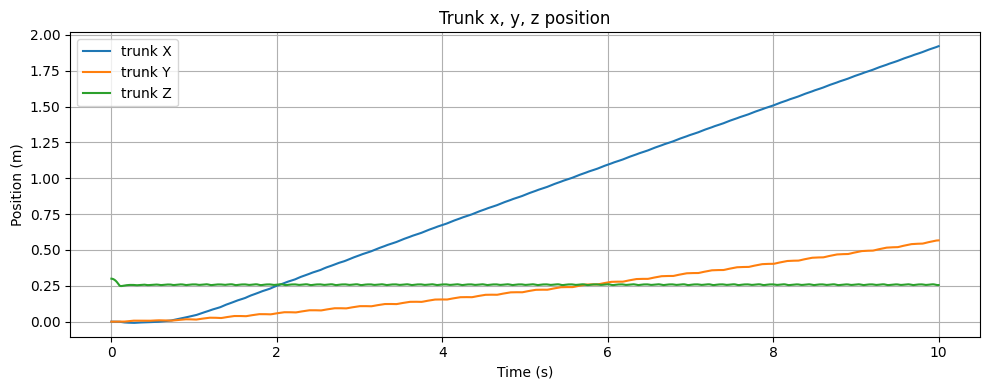

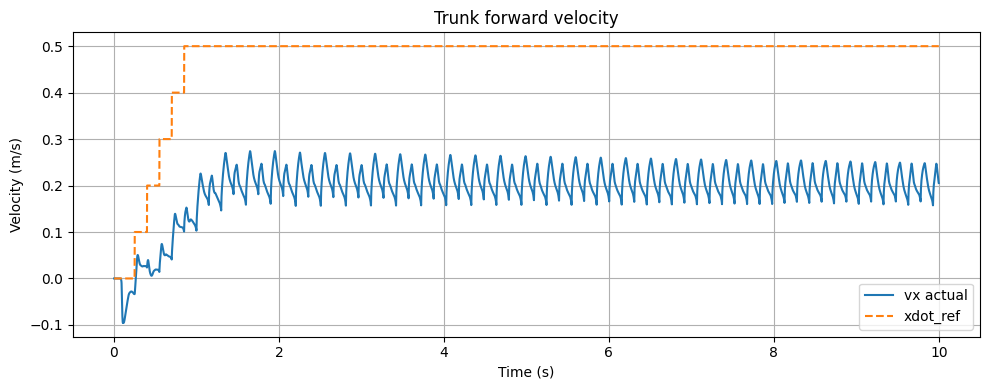

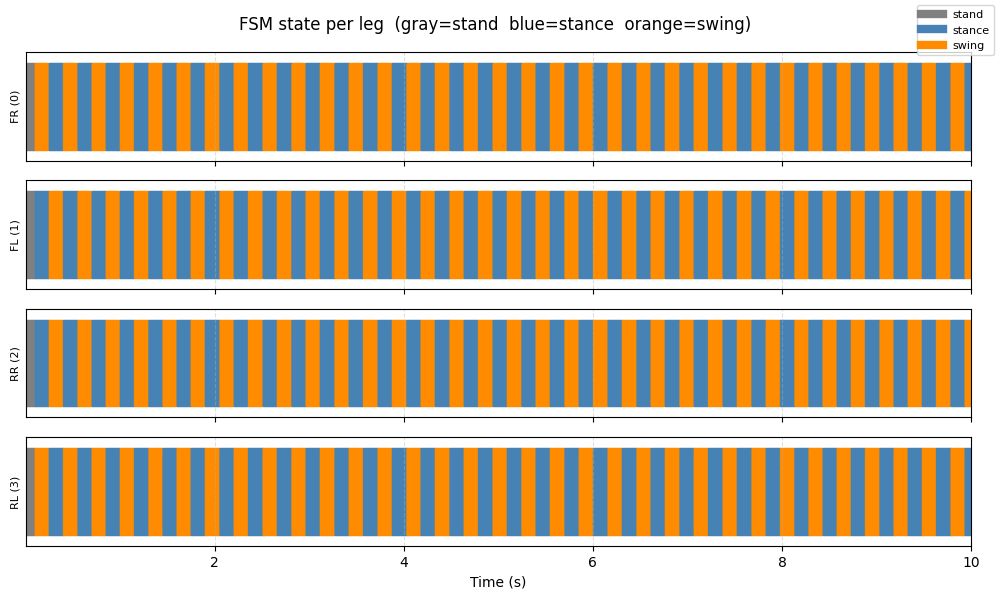

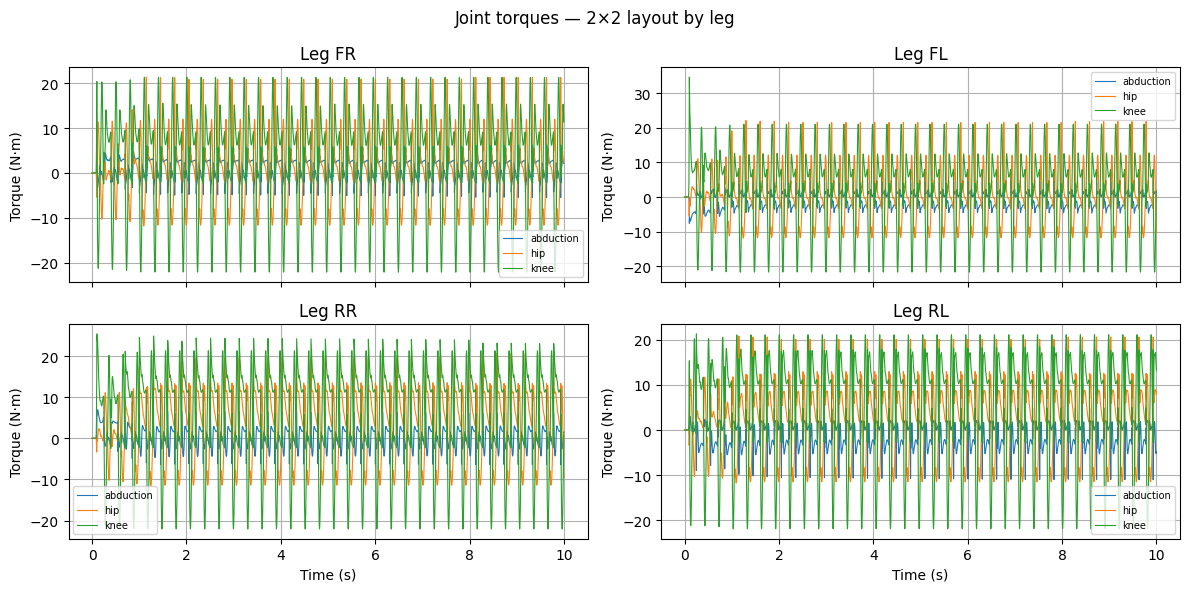

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Plot 1 — Trunk Position vs. Time
fig, ax = plt.subplots(figsize=(10,4))
for col, label in [('x','X'),('y','Y'),('z','Z')]:
    ax.plot(df['time'], df[col], label=f'trunk {label}')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Position (m)')
ax.set_title('Trunk x, y, z position')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()


#Plot 2 — Trunk Forward Velocity vs. Time
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df['time'], df['vx'], label='vx actual', color='tab:blue')
ax.plot(df['time'], df['xdot_ref'], '--', label='xdot_ref', color='tab:orange')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Velocity (m/s)')
ax.set_title('Trunk forward velocity')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()


#Plot 3: FSM State per Leg vs. Time
FSM_COLORS = {1: 'gray', 2: 'steelblue', 3: 'darkorange'}
LEG_NAMES  = ['FR (0)', 'FL (1)', 'RR (2)', 'RL (3)']

fig, axes = plt.subplots(4, 1, figsize=(10,6), sharex=True)
for idx, (ax, name) in enumerate(zip(axes, LEG_NAMES)):
    col = f'fsm{idx}'
    t   = df['time'].values
    fsm = df[col].values
    for i in range(len(t)-1):
        ax.fill_between([t[i],t[i+1]], idx+0.1, idx+0.9,
                        color=FSM_COLORS.get(fsm[i],'white'), alpha=0.85)
    ax.set_xlim(t[0], t[-1]); ax.set_ylim(idx, idx+1)
    ax.set_yticks([]); ax.set_ylabel(name, fontsize=8)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('FSM state per leg  (gray=stand  blue=stance  orange=swing)')
legend_els = [Line2D([0],[0],color='gray',lw=6,label='stand'),
              Line2D([0],[0],color='steelblue',lw=6,label='stance'),
              Line2D([0],[0],color='darkorange',lw=6,label='swing')]
fig.legend(handles=legend_els, loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()


## Plot 4: Joint Torques vs. Time (2×2 layout by leg)
LEG_LABELS  = ['FR', 'FL', 'RR', 'RL']
JOINT_LABELS= ['abduction', 'hip', 'knee']
COLORS      = ['tab:blue','tab:orange','tab:green']

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
for leg_idx, (ax, label) in enumerate(zip(axes.flat, LEG_LABELS)):
    for j_idx, (jlabel, col) in enumerate(zip(JOINT_LABELS, COLORS)):
        trq_col = f'trq{3*leg_idx+j_idx}'
        ax.plot(df['time'], df[trq_col], color=col, label=jlabel, lw=0.8)
    ax.set_title(f'Leg {label}'); ax.set_ylabel('Torque (N·m)')
    ax.legend(fontsize=7); ax.grid(True)
axes[1,0].set_xlabel('Time (s)'); axes[1,1].set_xlabel('Time (s)')
fig.suptitle('Joint torques — 2×2 layout by leg')
plt.tight_layout(); plt.show()


## Robot Walking Video (EGL / headless)

The `MUJOCO_GL=egl` environment variable set in cell 0 enables the EGL back-end used by
`mujoco.Renderer` — no display or GLFW window is needed.  The frames captured during the
simulation loop are assembled into an inline video with `mediapy`.


In [ ]:
import mediapy as media

print(f'Rendering {len(frames)} frames at {FPS} fps ...')
media.show_video(frames, fps=FPS, width=640)


Rendering 295 frames at 30 fps ...


This browser does not support the video tag.
